In [1]:
pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd

# Configuração
ticker_symbol = "BTC-USD"
file_name = "BTC-USD_daily_data.csv"

# Baixar os dados usando yfinance
print(f"Baixando dados históricos para {ticker_symbol}...")
try:
    data = yf.download(ticker_symbol, period="max", interval="1d")

    if data.empty:
        print(f"Nenhum dado encontrado para o ticker {ticker_symbol}.")
    else:
        # Passo 4: Salvar o DataFrame como um arquivo CSV no ambiente do Colab
        data.to_csv(file_name)
        print("-" * 50)
        print(f"Sucesso! O arquivo '{file_name}' foi salvo no ambiente temporário do Colab.")
        print("Você já pode usá-lo nas próximas células.")
        print("-" * 50)

except Exception as e:
    print(f"Ocorreu um erro: {e}")



Baixando dados históricos para BTC-USD...


/tmp/ipython-input-3515571476.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker_symbol, period="max", interval="1d")
[*********************100%***********************]  1 of 1 completed

--------------------------------------------------
Sucesso! O arquivo 'BTC-USD_daily_data.csv' foi salvo no ambiente temporário do Colab.
Você já pode usá-lo nas próximas células.
--------------------------------------------------


/tmp/ipython-input-1226891051.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download([btc_ticker, sp500_ticker], period="max", interval="1d")
[                       0%                       ]

Bibliotecas instaladas e importadas com sucesso!

Baixando dados históricos para BTC-USD e ^GSPC...


[*********************100%***********************]  2 of 2 completed


Download concluído com sucesso.
DataFrames de BTC e S&P 500 criados e limpos.

--- INICIANDO ANÁLISE ---

Gráfico 1: Retornos Diários do BTC gerado.


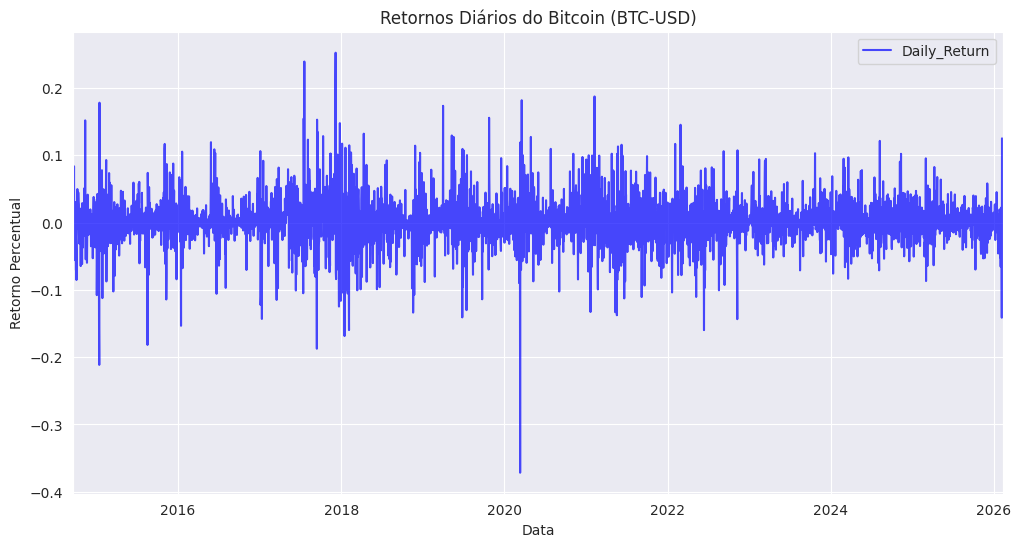


Gráfico 2: Preço e Médias Móveis do BTC gerado.


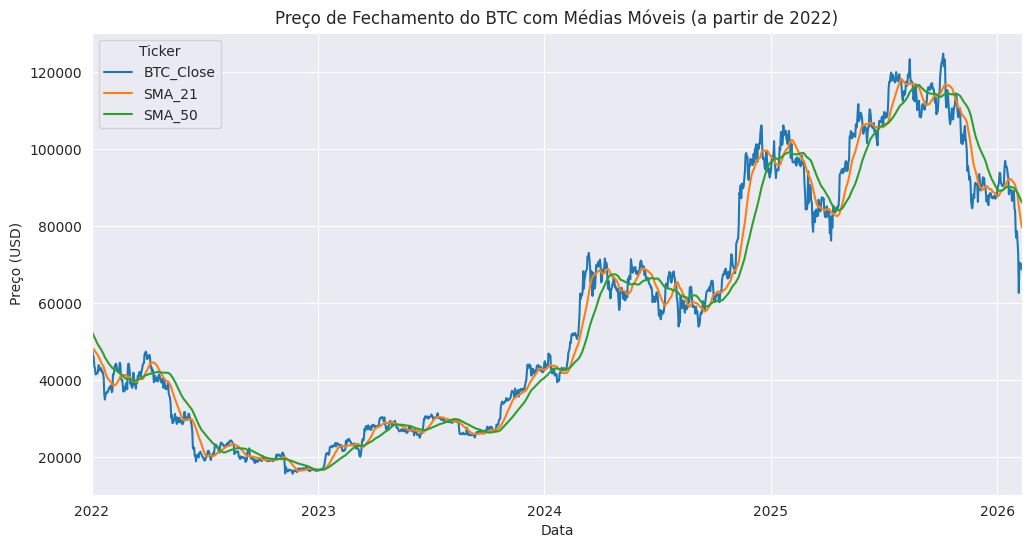


--- Estatísticas Descritivas dos Retornos Diários do BTC ---
count    4164.000000
mean        0.001829
std         0.035199
min        -0.371695
25%        -0.012526
50%         0.001145
75%         0.016022
max         0.252472
Name: Daily_Return, dtype: float64

Retorno Médio Diário (BTC): 0.1829%
Risco Diário (Desvio Padrão - BTC): 3.5199%

--- Análise de Correlação (Bônus) ---

Correlação entre os retornos diários do BTC e do S&P 500: 0.2317

Gráfico 3: Mapa de Calor da Correlação gerado.


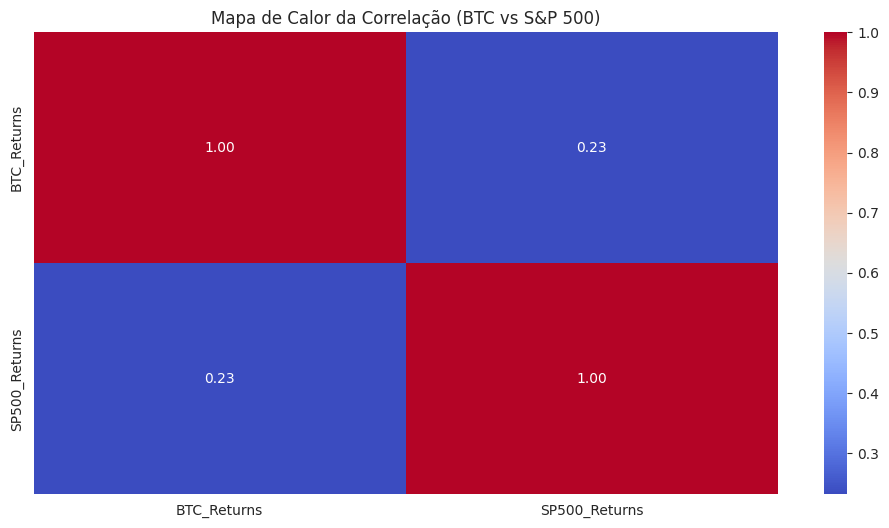


--- ANÁLISE CONCLUÍDA ---


In [3]:
# Bloco 1: Instalação e Importação das Bibliotecas
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Bibliotecas instaladas e importadas com sucesso!")


# Bloco 2: Aquisição e Preparação dos Dados
# Define os tickers dos ativos que queremos analisar
btc_ticker = "BTC-USD"
sp500_ticker = "^GSPC"

print(f"\nBaixando dados históricos para {btc_ticker} e {sp500_ticker}...")
try:
    # Baixa os dados para ambos os ativos de uma vez
    # O yfinance retorna um DataFrame com múltiplos níveis de colunas
    data = yf.download([btc_ticker, sp500_ticker], period="max", interval="1d")

    if data.empty:
        print("Nenhum dado foi baixado. Verifique os tickers.")
    else:
        print("Download concluído com sucesso.")

        # Seleciona apenas a coluna 'Close', que já é o preço ajustado
        # O yfinance cria um MultiIndex nas colunas, então selecionamos ('Close', 'BTC-USD')
        df_btc = data['Close'][[btc_ticker]].copy()
        df_sp500 = data['Close'][[sp500_ticker]].copy()

        # Renomeia as colunas para facilitar o uso
        df_btc.rename(columns={btc_ticker: 'BTC_Close'}, inplace=True)
        df_sp500.rename(columns={sp500_ticker: 'SP500_Close'}, inplace=True)

        # Remove quaisquer linhas com dados faltantes
        df_btc.dropna(inplace=True)
        df_sp500.dropna(inplace=True)

        print("DataFrames de BTC e S&P 500 criados e limpos.")

except Exception as e:
    print(f"Ocorreu um erro durante o download: {e}")


# Bloco 3: Análise Exploratória e Visualização de Dados
if 'df_btc' in locals() and not df_btc.empty:

    print("\n--- INICIANDO ANÁLISE ---")

    # 1. Análise dos Retornos Diários do BTC
    df_btc['Daily_Return'] = df_btc['BTC_Close'].pct_change()
    df_btc.dropna(inplace=True)

    plt.figure()
    df_btc['Daily_Return'].plot(title='Retornos Diários do Bitcoin (BTC-USD)', legend=True, color='blue', alpha=0.7)
    plt.ylabel('Retorno Percentual')
    plt.xlabel('Data')
    print("\nGráfico 1: Retornos Diários do BTC gerado.")
    plt.show()


    # 2. Análise com Médias Móveis do BTC
    df_btc['SMA_21'] = df_btc['BTC_Close'].rolling(window=21).mean()
    df_btc['SMA_50'] = df_btc['BTC_Close'].rolling(window=50).mean()

    plt.figure()
    df_btc.loc['2022-01-01':][['BTC_Close', 'SMA_21', 'SMA_50']].plot(title='Preço de Fechamento do BTC com Médias Móveis (a partir de 2022)', ax=plt.gca())
    plt.ylabel('Preço (USD)')
    plt.xlabel('Data')
    print("\nGráfico 2: Preço e Médias Móveis do BTC gerado.")
    plt.show()


    # 3. Análise Estatística do BTC
    print("\n--- Estatísticas Descritivas dos Retornos Diários do BTC ---")
    print(df_btc['Daily_Return'].describe())
    retorno_medio_diario = df_btc['Daily_Return'].mean()
    risco_diario = df_btc['Daily_Return'].std()
    print(f"\nRetorno Médio Diário (BTC): {retorno_medio_diario:.4%}")
    print(f"Risco Diário (Desvio Padrão - BTC): {risco_diario:.4%}")


    # --- 4. Análise de Correlação (BTC vs S&P 500) ---
    if 'df_sp500' in locals() and not df_sp500.empty:
        print("\n--- Análise de Correlação (Bônus) ---")
        # Calcula o retorno diário para o S&P 500
        df_sp500['Daily_Return'] = df_sp500['SP500_Close'].pct_change()
        df_sp500.dropna(inplace=True)

        # Combina os retornos em um único DataFrame, alinhando pelas datas
        combined_returns = pd.concat([df_btc['Daily_Return'], df_sp500['Daily_Return']], axis=1).dropna()
        combined_returns.columns = ['BTC_Returns', 'SP500_Returns']

        # Calcula a correlação
        correlation = combined_returns['BTC_Returns'].corr(combined_returns['SP500_Returns'])
        print(f"\nCorrelação entre os retornos diários do BTC e do S&P 500: {correlation:.4f}")

        # Gráfico 3: Mapa de Calor da Correlação
        plt.figure()
        sns.heatmap(combined_returns.corr(), annot=True, cmap='coolwarm', fmt=".2f")
        plt.title('Mapa de Calor da Correlação (BTC vs S&P 500)')
        print("\nGráfico 3: Mapa de Calor da Correlação gerado.")
        plt.show()

    print("\n--- ANÁLISE CONCLUÍDA ---")



--- INICIANDO BACKTEST PRECISO (COM LÓGICA DE CRUZAMENTO) ---
Sinais de cruzamento e posições de mercado gerados.
Retornos diários da estratégia calculados.
Crescimento do capital para ambas as estratégias calculado.

Gráfico de Performance gerado.


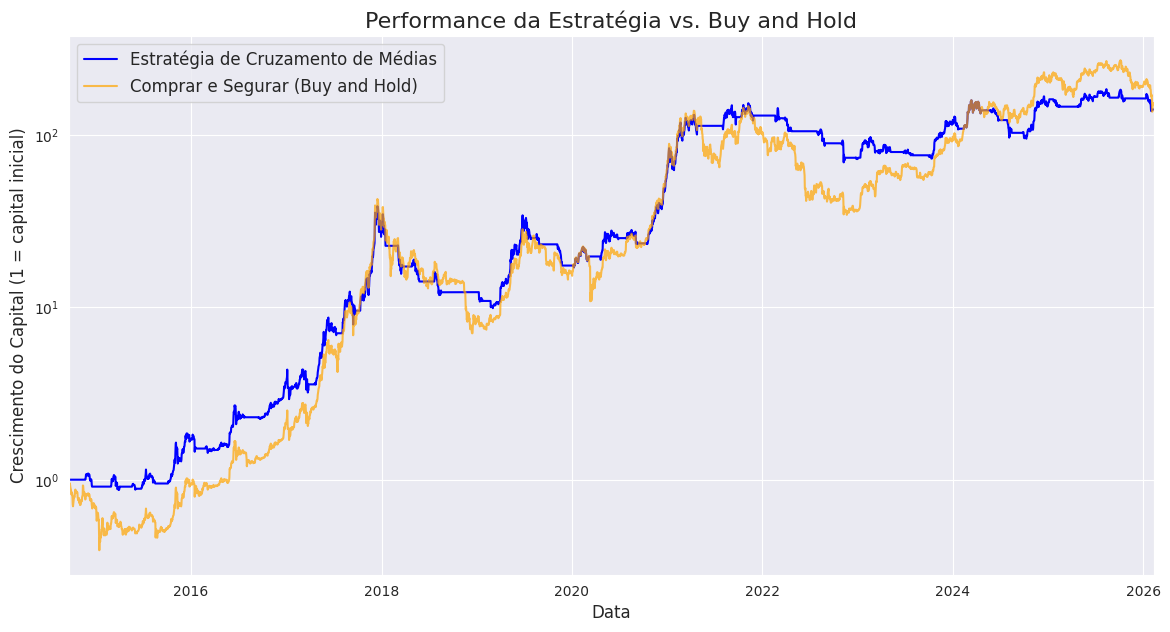


--- MÉTRICAS FINAIS DE PERFORMANCE ---
Retorno Total da Estratégia de Cruzamento: 141.13x
Retorno Total do Buy and Hold: 150.28x

Conclusão: A estratégia de Buy and Hold superou a de cruzamento de médias.

--- BACKTEST CONCLUÍDO ---


In [4]:
# Bloco 4: Backtesting Preciso com Lógica de Cruzamento
# Garante que o código só rode se o DataFrame 'df_btc' existir
if 'df_btc' in locals() and not df_btc.empty:

    print("\n--- INICIANDO BACKTEST PRECISO (COM LÓGICA DE CRUZAMENTO) ---")

    # 1. Geração de Sinais de Trade
    # Cópia para trabalhar e evitar avisos do Pandas
    df_strategy = df_btc.copy()

    # Identifica os pontos de cruzamento
    # Sinal de Compra (Golden Cross): Ocorre quando a SMA_21 cruza para CIMA da SMA_50
    # Sinal de Venda (Death Cross): Ocorre quando a SMA_21 cruza para BAIXO da SMA_50
    df_strategy['Sinal'] = 0 # Começamos sem sinal
    # Cruzamento para cima: SMA_21 > SMA_50 E no dia anterior era SMA_21 <= SMA_50
    df_strategy.loc[(df_strategy['SMA_21'] > df_strategy['SMA_50']) & (df_strategy['SMA_21'].shift(1) <= df_strategy['SMA_50'].shift(1)), 'Sinal'] = 1
    # Cruzamento para baixo: SMA_21 < SMA_50 E no dia anterior era SMA_21 >= SMA_50
    df_strategy.loc[(df_strategy['SMA_21'] < df_strategy['SMA_50']) & (df_strategy['SMA_21'].shift(1) >= df_strategy['SMA_50'].shift(1)), 'Sinal'] = -1 # -1 para venda

    # 2. Definição da Posição
    # Agora, a posição não é apenas o sinal do dia anterior. Ela deve ser mantida.
    # .ffill() (forward fill) para preencher os dias sem sinal com o último sinal válido.
    # Ex: Se houve um sinal de compra (1), mantemos a posição 1 até um sinal de venda (-1) aparecer.
    df_strategy['Posicao'] = df_strategy['Sinal'].replace(0, np.nan).ffill().fillna(0)
    # Trocar -1 por 0 para a estratégia "long-only" (ou compra ou fica fora)
    df_strategy['Posicao'] = df_strategy['Posicao'].replace(-1, 0)
    # Deslocar para evitar olhar para o futuro
    df_strategy['Posicao'] = df_strategy['Posicao'].shift(1).fillna(0)

    print("Sinais de cruzamento e posições de mercado gerados.")

    # 3. Cálculo do Retorno da Estratégia
    df_strategy['Retorno_Estrategia'] = df_strategy['Daily_Return'] * df_strategy['Posicao']

    print("Retornos diários da estratégia calculados.")

    # 4. Análise de Performance e Visualização
    df_strategy['Crescimento_Estrategia'] = (1 + df_strategy['Retorno_Estrategia']).cumprod()
    df_strategy['Crescimento_BuyAndHold'] = (1 + df_strategy['Daily_Return']).cumprod()

    print("Crescimento do capital para ambas as estratégias calculado.")

    # Gráfico Final: Comparação de Performance
    plt.figure(figsize=(14, 7))
    df_strategy['Crescimento_Estrategia'].plot(label='Estratégia de Cruzamento de Médias', color='blue')
    df_strategy['Crescimento_BuyAndHold'].plot(label='Comprar e Segurar (Buy and Hold)', color='orange', alpha=0.7)

    plt.title('Performance da Estratégia vs. Buy and Hold', fontsize=16)
    plt.ylabel('Crescimento do Capital (1 = capital inicial)', fontsize=12)
    plt.xlabel('Data', fontsize=12)
    plt.legend(fontsize=12)
    plt.yscale('log')
    print("\nGráfico de Performance gerado.")
    plt.show()

    # 5. Métricas Finais de Performance
    retorno_total_estrategia = df_strategy['Crescimento_Estrategia'].iloc[-1]
    retorno_total_buy_and_hold = df_strategy['Crescimento_BuyAndHold'].iloc[-1]

    print("\n--- MÉTRICAS FINAIS DE PERFORMANCE ---")
    print(f"Retorno Total da Estratégia de Cruzamento: {retorno_total_estrategia:.2f}x")
    print(f"Retorno Total do Buy and Hold: {retorno_total_buy_and_hold:.2f}x")

    if retorno_total_estrategia > retorno_total_buy_and_hold:
        print("\nConclusão: A estratégia de cruzamento de médias superou o Buy and Hold.")
    else:
        print("\nConclusão: A estratégia de Buy and Hold superou a de cruzamento de médias.")

    print("\n--- BACKTEST CONCLUÍDO ---")

else:
    print("\nO DataFrame 'df_btc' não foi encontrado. Por favor, execute os blocos de código anteriores primeiro.")



In [5]:
# Bloco 5: Análise Aprofundada da Estratégia e Métricas de Trade
# Garante que o código só rode se o DataFrame 'df_strategy' do backtest existir
if 'df_strategy' in locals() and not df_strategy.empty:

    print("\n--- ANÁLISE APROFUNDADA DA ESTRATÉGIA ---")

    # 1. Contagem de Trades
    # Um trade de compra ocorre quando a posição muda de 0 para 1.
    # Um trade de venda ocorre quando a posição muda de 1 para 0.
    # A coluna 'Sinal' já nos dá os pontos de cruzamento.
    # Compras são onde Sinal == 1, Vendas são onde Sinal == -1.
    num_compras = (df_strategy['Sinal'] == 1).sum()
    num_vendas = (df_strategy['Sinal'] == -1).sum()

    print(f"\nNúmero de Trades Executados:")
    print(f" - Compras (Entradas): {num_compras}")
    print(f" - Vendas (Saídas): {num_vendas}")
    print(f" - Total de Trades (Entrada + Saída): {num_compras + num_vendas}")


    # 2. Análise de Risco (Drawdown Máximo)
    # Drawdown é a medida da queda do pico ao fundo de um investimento.
    # É uma métrica de risco crucial.
    # Calcular o drawdown para ambas as estratégias.

    # Buy and Hold Drawdown
    cum_returns_bh = df_strategy['Crescimento_BuyAndHold']
    pico_bh = cum_returns_bh.cummax()
    drawdown_bh = (cum_returns_bh - pico_bh) / pico_bh
    max_drawdown_bh = drawdown_bh.min()

    # Estratégia Drawdown
    cum_returns_strat = df_strategy['Crescimento_Estrategia']
    pico_strat = cum_returns_strat.cummax()
    drawdown_strat = (cum_returns_strat - pico_strat) / pico_strat
    max_drawdown_strat = drawdown_strat.min()

    print("\nAnálise de Risco (Queda Máxima do Pico ao Fundo):")
    print(f" - Drawdown Máximo do Buy and Hold: {max_drawdown_bh:.2%}")
    print(f" - Drawdown Máximo da Estratégia: {max_drawdown_strat:.2%}")


    # 3. Retorno Anualizado e Volatilidade
    # Para comparar de forma justa, anualizamos as métricas.
    dias_no_ano = 252 # Dias de trade em um ano típico

    # Retorno Anualizado
    retorno_anual_bh = (df_strategy['Crescimento_BuyAndHold'].iloc[-1])**(dias_no_ano/len(df_strategy)) - 1
    retorno_anual_strat = (df_strategy['Crescimento_Estrategia'].iloc[-1])**(dias_no_ano/len(df_strategy)) - 1

    # Volatilidade Anualizada (Risco)
    vol_anual_bh = df_strategy['Daily_Return'].std() * np.sqrt(dias_no_ano)
    vol_anual_strat = df_strategy['Retorno_Estrategia'].std() * np.sqrt(dias_no_ano)

    print("\nMétricas Anualizadas:")
    print(f" - Retorno Anualizado do Buy and Hold: {retorno_anual_bh:.2%}")
    print(f" - Retorno Anualizado da Estratégia: {retorno_anual_strat:.2%}")
    print(f" - Volatilidade Anualizada do Buy and Hold: {vol_anual_bh:.2%}")
    print(f" - Volatilidade Anualizada da Estratégia: {vol_anual_strat:.2%}")


    # 4. Sharpe Ratio (Índice de Sharpe)
    # A métrica mais famosa de retorno ajustado ao risco. (Assumindo taxa livre de risco = 0)
    sharpe_ratio_bh = retorno_anual_bh / vol_anual_bh
    sharpe_ratio_strat = retorno_anual_strat / vol_anual_strat

    print("\nRetorno Ajustado ao Risco (Índice de Sharpe):")
    print(f" - Sharpe Ratio do Buy and Hold: {sharpe_ratio_bh:.2f}")
    print(f" - Sharpe Ratio da Estratégia: {sharpe_ratio_strat:.2f}")

    print("\n--- ANÁLISE APROFUNDADA CONCLUÍDA ---")

else:
    print("\nO DataFrame 'df_strategy' não foi encontrado. Por favor, execute o bloco de backtest primeiro.")




--- ANÁLISE APROFUNDADA DA ESTRATÉGIA ---

Número de Trades Executados:
 - Compras (Entradas): 45
 - Vendas (Saídas): 45
 - Total de Trades (Entrada + Saída): 90

Análise de Risco (Queda Máxima do Pico ao Fundo):
 - Drawdown Máximo do Buy and Hold: -83.40%
 - Drawdown Máximo da Estratégia: -74.40%

Métricas Anualizadas:
 - Retorno Anualizado do Buy and Hold: 35.44%
 - Retorno Anualizado da Estratégia: 34.92%
 - Volatilidade Anualizada do Buy and Hold: 55.88%
 - Volatilidade Anualizada da Estratégia: 41.01%

Retorno Ajustado ao Risco (Índice de Sharpe):
 - Sharpe Ratio do Buy and Hold: 0.63
 - Sharpe Ratio da Estratégia: 0.85

--- ANÁLISE APROFUNDADA CONCLUÍDA ---



--- INICIANDO OTIMIZAÇÃO DE PARÂMETROS ---

--- Testando Combinação: SMA 10/30 ---


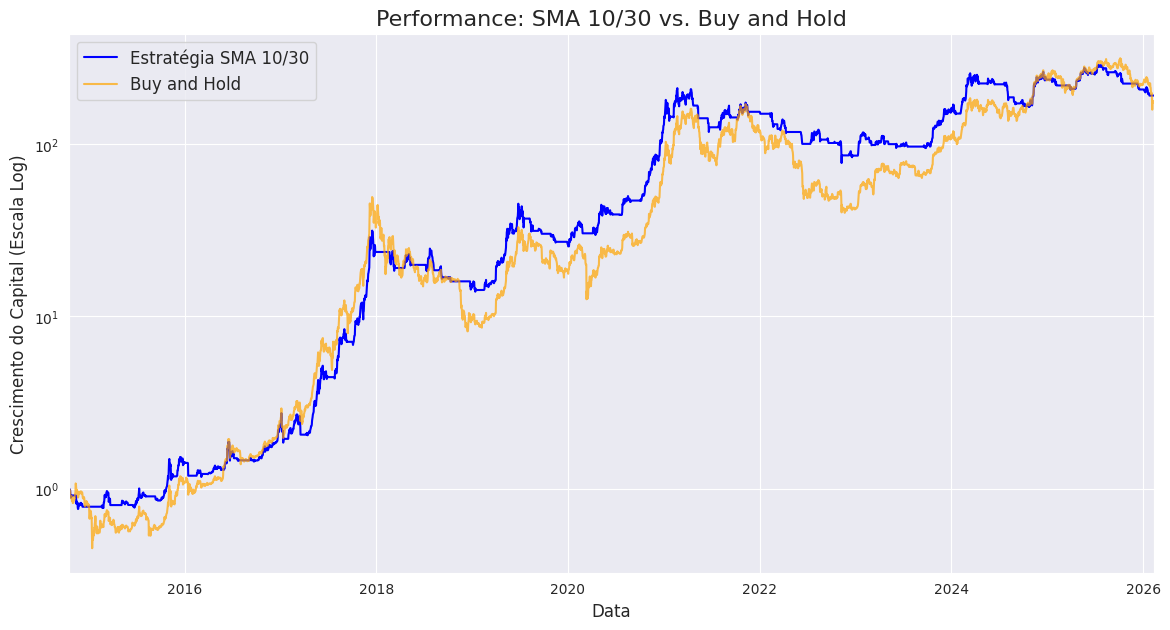


--- Testando Combinação: SMA 21/50 ---


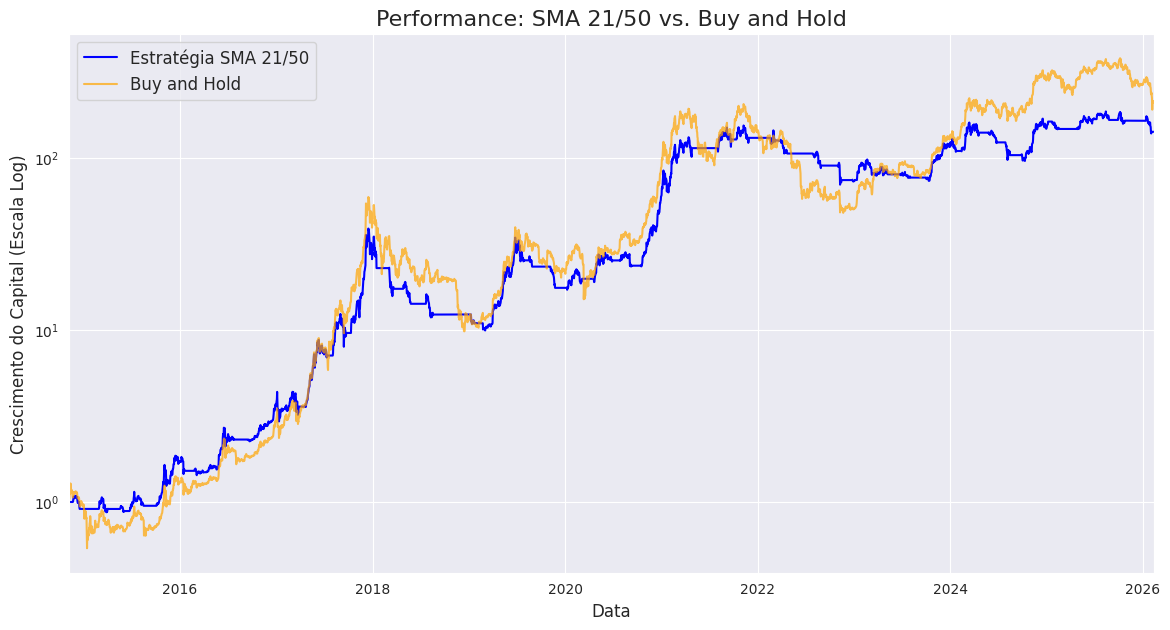


--- Testando Combinação: SMA 50/200 ---


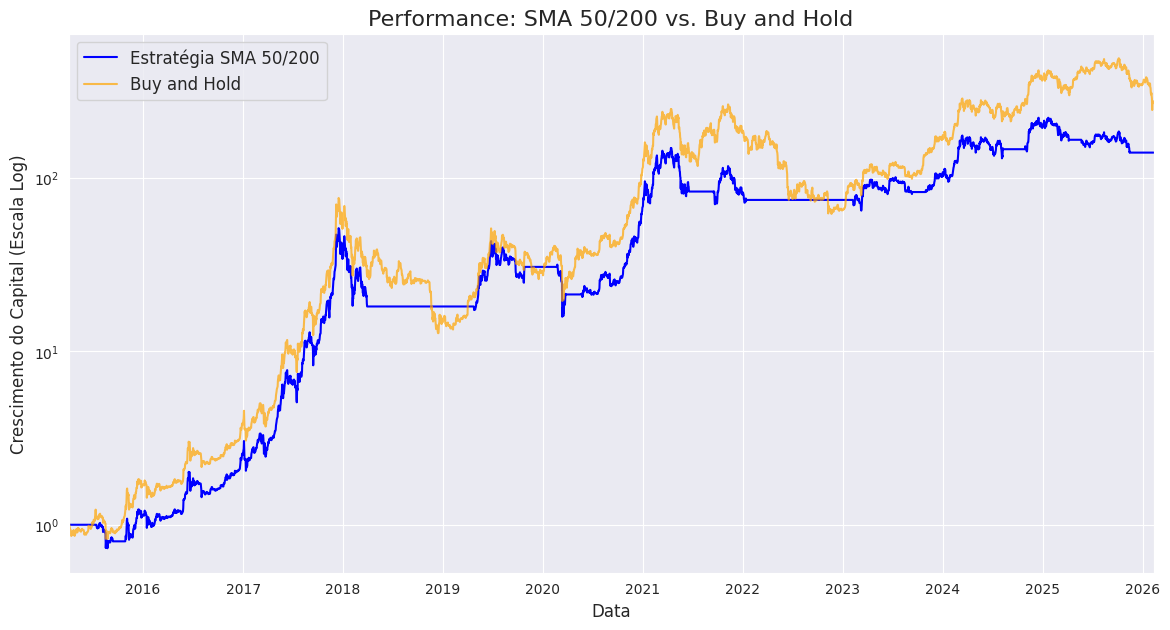


--- TABELA COMPARATIVA DE RESULTADOS ---
Combinação Retorno Total Retorno Anualizado Volatilidade Anualizada Drawdown Máximo Índice de Sharpe  Total de Trades
     10/30       191.79x             37.75%                  39.50%         -63.25%             0.96              154
     21/50       141.13x             35.40%                  41.25%         -74.40%             0.86               90
    50/200       140.07x             36.89%                  46.98%         -69.15%             0.79               20

--- MÉTRICAS DE REFERÊNCIA (BUY AND HOLD) ---
Retorno Total: 150.28x
Retorno Anualizado: 4.99%
Volatilidade Anualizada: 55.88%
Drawdown Máximo: -83.40%
Índice de Sharpe: 0.09


In [6]:
# Bloco 6: Otimização de Parâmetros da Estratégia
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Garante que o código só rode se o DataFrame 'data' com os preços existir
if 'data' in locals() and not data.empty:

    print("\n--- INICIANDO OTIMIZAÇÃO DE PARÂMETROS ---")

    # 1. Definindo a Função de Backtest
    def rodar_backtest(dataframe_precos, periodo_curto, periodo_longo):
        """
        Executa um backtest completo para uma estratégia de cruzamento de médias móveis.

        Args:
            dataframe_precos (pd.DataFrame): DataFrame com a coluna de preços 'BTC_Close'.
            periodo_curto (int): O número de dias para a média móvel curta.
            periodo_longo (int): O número de dias para a média móvel longa.

        Returns:
            pd.DataFrame: Um DataFrame com os resultados e métricas da estratégia.
        """
        print(f"\n--- Testando Combinação: SMA {periodo_curto}/{periodo_longo} ---")

        df_strategy = dataframe_precos.copy()
        df_strategy.rename(columns={'BTC-USD': 'BTC_Close'}, inplace=True)
        df_strategy.dropna(inplace=True)

        # Cálculo das Médias Móveis
        df_strategy[f'SMA_{periodo_curto}'] = df_strategy['BTC_Close'].rolling(window=periodo_curto).mean()
        df_strategy[f'SMA_{periodo_longo}'] = df_strategy['BTC_Close'].rolling(window=periodo_longo).mean()

        # Geração de Sinais
        df_strategy['Sinal'] = 0
        df_strategy.loc[(df_strategy[f'SMA_{periodo_curto}'] > df_strategy[f'SMA_{periodo_longo}']) & (df_strategy[f'SMA_{periodo_curto}'].shift(1) <= df_strategy[f'SMA_{periodo_longo}'].shift(1)), 'Sinal'] = 1
        df_strategy.loc[(df_strategy[f'SMA_{periodo_curto}'] < df_strategy[f'SMA_{periodo_longo}']) & (df_strategy[f'SMA_{periodo_curto}'].shift(1) >= df_strategy[f'SMA_{periodo_longo}'].shift(1)), 'Sinal'] = -1

        # Definição da Posição
        df_strategy['Posicao'] = df_strategy['Sinal'].replace(0, np.nan).ffill().fillna(0)
        df_strategy['Posicao'] = df_strategy['Posicao'].replace(-1, 0)
        df_strategy['Posicao'] = df_strategy['Posicao'].shift(1).fillna(0)

        # Cálculo dos Retornos
        df_strategy['Daily_Return'] = df_strategy['BTC_Close'].pct_change()
        df_strategy['Retorno_Estrategia'] = df_strategy['Daily_Return'] * df_strategy['Posicao']
        df_strategy.dropna(inplace=True)

        # Cálculo do Crescimento do Capital
        df_strategy['Crescimento_Estrategia'] = (1 + df_strategy['Retorno_Estrategia']).cumprod()
        df_strategy['Crescimento_BuyAndHold'] = (1 + df_strategy['Daily_Return']).cumprod()

        # Cálculo das Métricas
        retorno_total_strat = df_strategy['Crescimento_Estrategia'].iloc[-1]
        retorno_total_bh = df_strategy['Crescimento_BuyAndHold'].iloc[-1]
        num_compras = (df_strategy['Sinal'] == 1).sum()
        num_vendas = (df_strategy['Sinal'] == -1).sum()

        dias_no_ano = 252
        retorno_anual_strat = (retorno_total_strat)**(dias_no_ano/len(df_strategy)) - 1
        vol_anual_strat = df_strategy['Retorno_Estrategia'].std() * np.sqrt(dias_no_ano)
        sharpe_ratio_strat = retorno_anual_strat / vol_anual_strat if vol_anual_strat > 0 else 0

        cum_returns_strat = df_strategy['Crescimento_Estrategia']
        pico_strat = cum_returns_strat.cummax()
        drawdown_strat = (cum_returns_strat - pico_strat) / pico_strat
        max_drawdown_strat = drawdown_strat.min()

        # Plot do Gráfico de Performance
        plt.figure(figsize=(14, 7))
        df_strategy['Crescimento_Estrategia'].plot(label=f'Estratégia SMA {periodo_curto}/{periodo_longo}', color='blue')
        df_strategy['Crescimento_BuyAndHold'].plot(label='Buy and Hold', color='orange', alpha=0.7)
        plt.title(f'Performance: SMA {periodo_curto}/{periodo_longo} vs. Buy and Hold', fontsize=16)
        plt.ylabel('Crescimento do Capital (Escala Log)', fontsize=12)
        plt.xlabel('Data', fontsize=12)
        plt.legend(fontsize=12)
        plt.yscale('log')
        plt.show()

        return {
            'Combinação': f'{periodo_curto}/{periodo_longo}',
            'Retorno Total': f'{retorno_total_strat:.2f}x',
            'Retorno Anualizado': f'{retorno_anual_strat:.2%}',
            'Volatilidade Anualizada': f'{vol_anual_strat:.2%}',
            'Drawdown Máximo': f'{max_drawdown_strat:.2%}',
            'Índice de Sharpe': f'{sharpe_ratio_strat:.2f}',
            'Total de Trades': num_compras + num_vendas
        }

    # 2. Executando os Testes
    # Seleciona apenas os dados de preço do BTC
    btc_prices = data['Close'][['BTC-USD']].copy()

    # Lista de combinações para testar
    combinacoes = [(10, 30), (21, 50), (50, 200)]
    resultados = []

    for curto, longo in combinacoes:
        resultado = rodar_backtest(btc_prices, curto, longo)
        resultados.append(resultado)

    # 3. Exibindo a Tabela Comparativa de Resultados
    df_resultados = pd.DataFrame(resultados)
    print("\n--- TABELA COMPARATIVA DE RESULTADOS ---")
    print(df_resultados.to_string(index=False))

    # Adicionando as métricas do Buy and Hold para referência
    df_bh = btc_prices.copy()
    df_bh.rename(columns={'BTC-USD': 'BTC_Close'}, inplace=True)
    df_bh['Daily_Return'] = df_bh['BTC_Close'].pct_change().dropna()
    retorno_total_bh = (1 + df_bh['Daily_Return']).cumprod().iloc[-1]
    retorno_anual_bh = (retorno_total_bh)**(252/len(df_bh)) - 1
    vol_anual_bh = df_bh['Daily_Return'].std() * np.sqrt(252)
    sharpe_ratio_bh = retorno_anual_bh / vol_anual_bh
    cum_returns_bh = (1 + df_bh['Daily_Return']).cumprod()
    pico_bh = cum_returns_bh.cummax()
    drawdown_bh = (cum_returns_bh - pico_bh) / pico_bh
    max_drawdown_bh = drawdown_bh.min()

    print("\n--- MÉTRICAS DE REFERÊNCIA (BUY AND HOLD) ---")
    print(f"Retorno Total: {retorno_total_bh:.2f}x")
    print(f"Retorno Anualizado: {retorno_anual_bh:.2%}")
    print(f"Volatilidade Anualizada: {vol_anual_bh:.2%}")
    print(f"Drawdown Máximo: {max_drawdown_bh:.2%}")
    print(f"Índice de Sharpe: {sharpe_ratio_bh:.2f}")

else:
    print("\nO DataFrame 'data' não foi encontrado. Por favor, execute os blocos de código anteriores primeiro.")




--- INICIANDO BACKTEST ROBUSTO (COM CUSTOS E ANÁLISE DETALHADA) ---
Estratégia: SMA 10/30


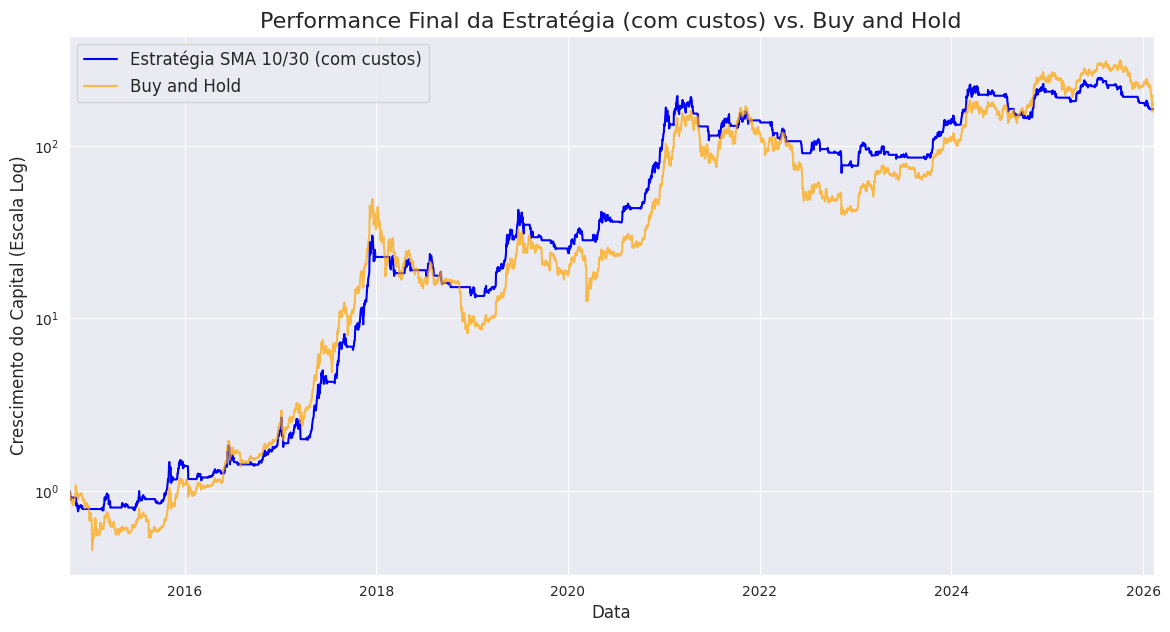


--- TABELA FINAL DE MÉTRICAS DE ROBUSTEZ (SMA 10/30) ---
- Retorno Total (com custos): 164.34x
- Retorno Anualizado (com custos): 36.46%
- Volatilidade Anualizada: 39.51%
- Drawdown Máximo: -64.27%
- Índice de Sharpe (com custos): 0.92
- Total de Trades: 3
- Percentual de Trades Vencedores: 66.67%
- Média de Ganho (por trade vencedor): 3.46%
- Média de Perda (por trade perdedor): -0.10%
- Payoff Ratio (Ganho/Perda): 34.61

--- ANÁLISE CONCLUÍDA ---


In [7]:
# Bloco 7: Backtest Robusto (SMA 10/30) com Custos e Análise de Trades
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Garante que o código só rode se o DataFrame 'data' com os preços existir
if 'data' in locals() and not data.empty:

    print("\n--- INICIANDO BACKTEST ROBUSTO (COM CUSTOS E ANÁLISE DETALHADA) ---")
    print("Estratégia: SMA 10/30")

    # 1. Preparação dos Dados
    df_final = data['Close'][['BTC-USD']].copy()
    df_final.rename(columns={'BTC-USD': 'BTC_Close'}, inplace=True)
    df_final.dropna(inplace=True)

    # Definição dos parâmetros
    periodo_curto = 10
    periodo_longo = 30
    custo_transacao = 0.001 # 0.1%

    # Cálculo das Médias Móveis
    df_final[f'SMA_{periodo_curto}'] = df_final['BTC_Close'].rolling(window=periodo_curto).mean()
    df_final[f'SMA_{periodo_longo}'] = df_final['BTC_Close'].rolling(window=periodo_longo).mean()

    # Geração de Sinais de Cruzamento
    df_final['Sinal'] = 0
    df_final.loc[(df_final[f'SMA_{periodo_curto}'] > df_final[f'SMA_{periodo_longo}']) & (df_final[f'SMA_{periodo_curto}'].shift(1) <= df_final[f'SMA_{periodo_longo}'].shift(1)), 'Sinal'] = 1
    df_final.loc[(df_final[f'SMA_{periodo_curto}'] < df_final[f'SMA_{periodo_longo}']) & (df_final[f'SMA_{periodo_curto}'].shift(1) >= df_final[f'SMA_{periodo_longo}'].shift(1)), 'Sinal'] = -1

    # Definição da Posição
    df_final['Posicao'] = df_final['Sinal'].replace(0, np.nan).ffill().fillna(0)
    df_final['Posicao'] = df_final['Posicao'].replace(-1, 0)
    df_final['Posicao'] = df_final['Posicao'].shift(1).fillna(0)

    # 2. Cálculo dos Retornos com Custos
    df_final['Daily_Return'] = df_final['BTC_Close'].pct_change()

    # Identifica os dias em que um trade ocorre (mudança de posição)
    df_final['Trade'] = df_final['Posicao'].diff().abs()
    # Aplica o custo da transação nos dias de trade
    df_final['Custo'] = df_final['Trade'] * custo_transacao
    # Calcula o retorno líquido da estratégia
    df_final['Retorno_Estrategia'] = (df_final['Daily_Return'] * df_final['Posicao']) - df_final['Custo']
    df_final.dropna(inplace=True)

    # 3. Análise de Performance e Visualização
    df_final['Crescimento_Estrategia'] = (1 + df_final['Retorno_Estrategia']).cumprod()
    df_final['Crescimento_BuyAndHold'] = (1 + df_final['Daily_Return']).cumprod()

    plt.figure(figsize=(14, 7))
    df_final['Crescimento_Estrategia'].plot(label='Estratégia SMA 10/30 (com custos)', color='blue')
    df_final['Crescimento_BuyAndHold'].plot(label='Buy and Hold', color='orange', alpha=0.7)
    plt.title('Performance Final da Estratégia (com custos) vs. Buy and Hold', fontsize=16)
    plt.ylabel('Crescimento do Capital (Escala Log)', fontsize=12)
    plt.xlabel('Data', fontsize=12)
    plt.legend(fontsize=12)
    plt.yscale('log')
    plt.show()

    # 4. Análise de Trades Individuais
    trades = df_final[df_final['Sinal'] != 0].copy()
    trades['Retorno_Trade'] = (df_final['Crescimento_Estrategia'].pct_change() * trades['Sinal'].shift(-1) * -1).shift(-1)
    trades.dropna(inplace=True)

    trades_vencedores = trades[trades['Retorno_Trade'] > 0]
    trades_perdedores = trades[trades['Retorno_Trade'] < 0]

    percentual_vencedor = (len(trades_vencedores) / len(trades)) * 100 if len(trades) > 0 else 0
    media_ganho = trades_vencedores['Retorno_Trade'].mean() if len(trades_vencedores) > 0 else 0
    media_perda = trades_perdedores['Retorno_Trade'].mean() if len(trades_perdedores) > 0 else 0
    payoff_ratio = abs(media_ganho / media_perda) if media_perda != 0 else 0

    # 5. Exibição da Tabela Final de Métricas
    retorno_total_strat = df_final['Crescimento_Estrategia'].iloc[-1]
    retorno_anual_strat = (retorno_total_strat)**(252/len(df_final)) - 1
    vol_anual_strat = df_final['Retorno_Estrategia'].std() * np.sqrt(252)
    sharpe_ratio_strat = retorno_anual_strat / vol_anual_strat if vol_anual_strat > 0 else 0
    max_drawdown_strat = ((df_final['Crescimento_Estrategia'] - df_final['Crescimento_Estrategia'].cummax()) / df_final['Crescimento_Estrategia'].cummax()).min()

    print("\n--- TABELA FINAL DE MÉTRICAS DE ROBUSTEZ (SMA 10/30) ---")
    metricas = {
        "Retorno Total (com custos)": f"{retorno_total_strat:.2f}x",
        "Retorno Anualizado (com custos)": f"{retorno_anual_strat:.2%}",
        "Volatilidade Anualizada": f"{vol_anual_strat:.2%}",
        "Drawdown Máximo": f"{max_drawdown_strat:.2%}",
        "Índice de Sharpe (com custos)": f"{sharpe_ratio_strat:.2f}",
        "Total de Trades": len(trades),
        "Percentual de Trades Vencedores": f"{percentual_vencedor:.2f}%",
        "Média de Ganho (por trade vencedor)": f"{media_ganho:.2%}",
        "Média de Perda (por trade perdedor)": f"{media_perda:.2%}",
        "Payoff Ratio (Ganho/Perda)": f"{payoff_ratio:.2f}"
    }
    for nome, valor in metricas.items():
        print(f"- {nome}: {valor}")

    print("\n--- ANÁLISE CONCLUÍDA ---")

else:
    print("\nO DataFrame 'data' não foi encontrado. Por favor, execute os blocos de código anteriores primeiro.")



--- FASE 4: INICIANDO EXPLORAÇÃO DE DADOS INTRADIÁRIOS ---

Baixando dados intradiários de 1 hora para o BTC-USD (período de 2 anos)...


/tmp/ipython-input-1442276179.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_intraday = yf.download(tickers="BTC-USD", period="2y", interval="1h")
[*********************100%***********************]  1 of 1 completed


Download concluído com sucesso.

Primeiras 5 linhas dos dados intradiários:
Price                             Close          High           Low  \
Ticker                          BTC-USD       BTC-USD       BTC-USD   
Datetime                                                              
2024-02-10 21:00:00+00:00  47938.394531  48124.164062  47811.734375   
2024-02-10 22:00:00+00:00  47815.417969  47951.070312  47664.570312   
2024-02-10 23:00:00+00:00  47768.953125  47940.402344  47742.511719   
2024-02-11 00:00:00+00:00  47747.382812  47786.863281  47650.062500   
2024-02-11 01:00:00+00:00  47647.375000  47770.585938  47617.406250   

Price                              Open  Volume  
Ticker                          BTC-USD BTC-USD  
Datetime                                         
2024-02-10 21:00:00+00:00  47890.628906       0  
2024-02-10 22:00:00+00:00  47951.070312       0  
2024-02-10 23:00:00+00:00  47835.578125       0  
2024-02-11 00:00:00+00:00  47768.968750       0  
2024-

<Figure size 1400x700 with 0 Axes>

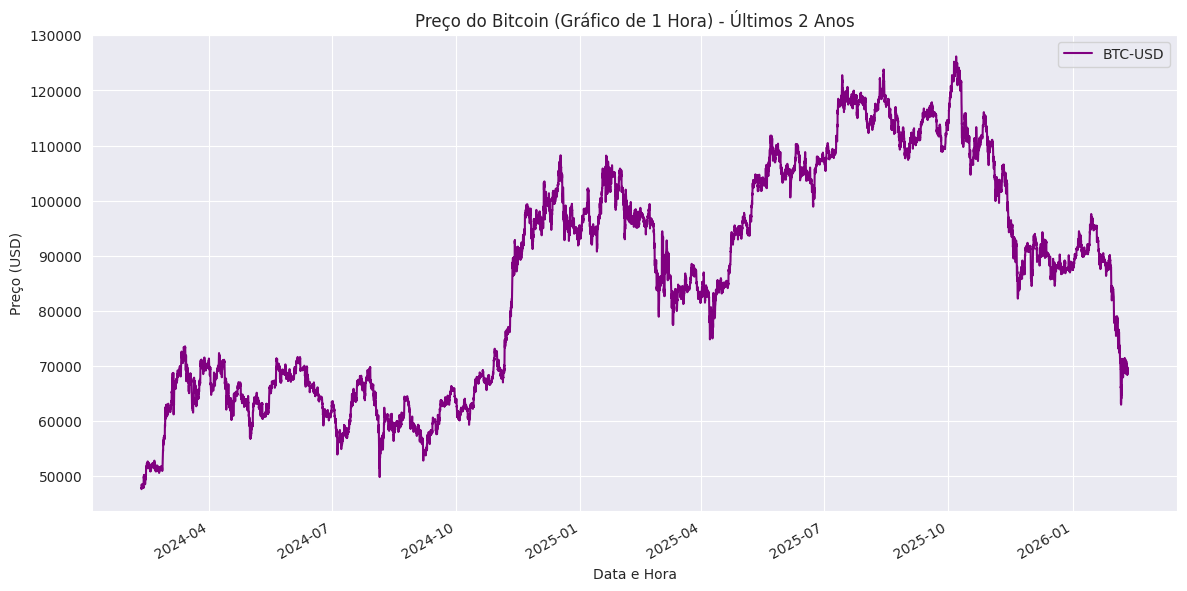


--- ANÁLISE EXPLORATÓRIA INICIAL CONCLUÍDA ---
Observe a natureza do gráfico: a quantidade de movimentos bruscos e 'ruído' em comparação com o gráfico diário.
Este é o ambiente em que as estratégias de curto prazo operam.


In [8]:
# Bloco 8: Exploração de Dados Intradiários (Day Trade / Scalping)
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (14, 7)

print("--- FASE 4: INICIANDO EXPLORAÇÃO DE DADOS INTRADIÁRIOS ---")

try:
    # 1. Obtenção de Dados Intradiários
    # Baixar os dados do Bitcoin (BTC-USD) com um intervalo de 1 hora ("1h").
    # O período "2y" busca os dados dos últimos 2 anos.
    # O yfinance pode ter limitações na quantidade de dados intradiários que fornece.
    print("\nBaixando dados intradiários de 1 hora para o BTC-USD (período de 2 anos)...")
    df_intraday = yf.download(tickers="BTC-USD", period="2y", interval="1h")

    if df_intraday.empty:
        print("\nNão foi possível baixar os dados intradiários. A API pode estar indisponível ou o período é muito longo.")
        print("Tentando um período menor (últimos 60 dias)...")
        df_intraday = yf.download(tickers="BTC-USD", period="60d", interval="1h")

    if not df_intraday.empty:
        print("Download concluído com sucesso.")
        print("\nPrimeiras 5 linhas dos dados intradiários:")
        print(df_intraday.head())

        # 2. Primeira Análise Exploratória
        # Plotamos o preço de fechamento para ter uma ideia visual do "ruído" e da volatilidade.
        plt.figure()
        df_intraday['Close'].plot(title='Preço do Bitcoin (Gráfico de 1 Hora) - Últimos 2 Anos',
                                 label='Preço de Fechamento (1h)',
                                 color='purple')
        plt.ylabel('Preço (USD)')
        plt.xlabel('Data e Hora')
        plt.legend()
        print("\nGráfico de preço intradiário gerado.")
        plt.show()

        print("\n--- ANÁLISE EXPLORATÓRIA INICIAL CONCLUÍDA ---")
        print("Observe a natureza do gráfico: a quantidade de movimentos bruscos e 'ruído' em comparação com o gráfico diário.")
        print("Este é o ambiente em que as estratégias de curto prazo operam.")

    else:
        print("\nFalha ao baixar os dados intradiários mesmo com um período menor. Não podemos prosseguir com a análise.")


except Exception as e:
    print(f"\nOcorreu um erro inesperado: {e}")
    print("Não foi possível concluir a análise de dados intradiários.")




--- INICIANDO BACKTEST DE ESTRATÉGIA INTRADIÁRIA (BANDAS DE BOLLINGER) ---
Indicadores (Bandas de Bollinger) calculados.
Sinais e posições de Day Trade gerados.
Crescimento do capital calculado.


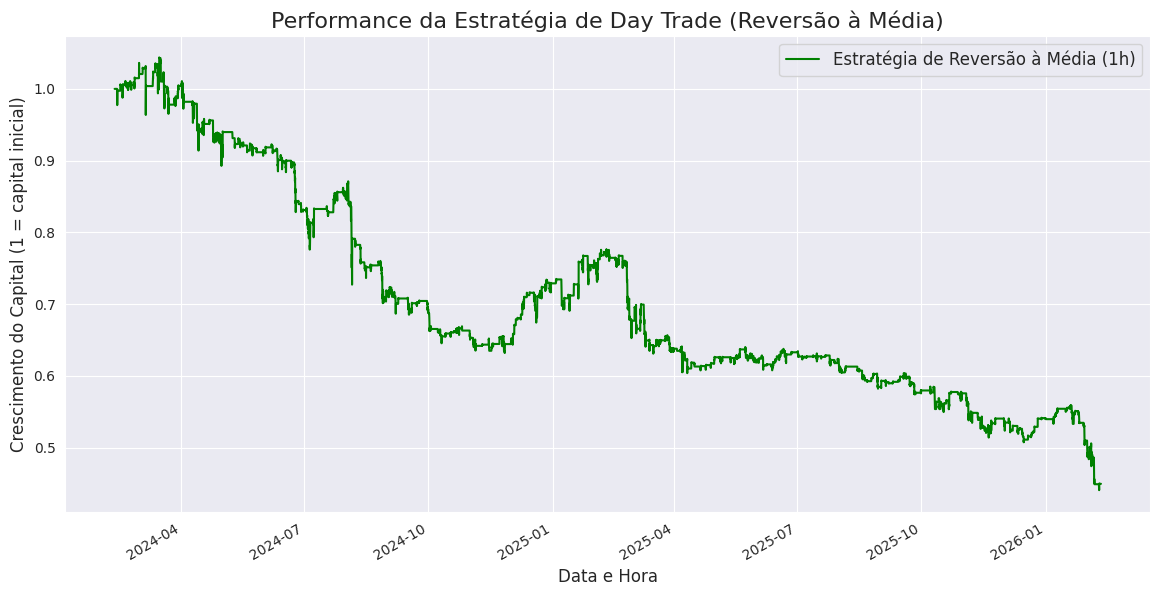


--- MÉTRICAS DA ESTRATÉGIA DE DAY TRADE ---
Retorno Total da Estratégia: 0.45x
Conclusão: A estratégia resultou em prejuízo.

--- ANÁLISE DE DAY TRADE CONCLUÍDA ---


In [9]:
# Bloco 9: Backtest de Estratégia Intradiária (Reversão à Média com Bandas de Bollinger)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Garante que o código só rode se o DataFrame 'df_intraday' existir
if 'df_intraday' in locals() and not df_intraday.empty:

    print("\n--- INICIANDO BACKTEST DE ESTRATÉGIA INTRADIÁRIA (BANDAS DE BOLLINGER) ---")

    # 1. Preparação dos Dados e Cálculo do Indicador
    # Usar apenas a coluna de fechamento
    df_daytrade = pd.DataFrame(df_intraday['Close'])
    df_daytrade.columns = ['Preco']

    # Parâmetros das Bandas de Bollinger
    periodo_media = 20  # Média de 20 horas
    num_desvios = 2     # 2 desvios padrão

    # Cálculo da Média Móvel e do Desvio Padrão
    df_daytrade['SMA'] = df_daytrade['Preco'].rolling(window=periodo_media).mean()
    df_daytrade['StdDev'] = df_daytrade['Preco'].rolling(window=periodo_media).std()

    # Cálculo das Bandas Superior e Inferior
    df_daytrade['Banda_Superior'] = df_daytrade['SMA'] + (df_daytrade['StdDev'] * num_desvios)
    df_daytrade['Banda_Inferior'] = df_daytrade['SMA'] - (df_daytrade['StdDev'] * num_desvios)

    df_daytrade.dropna(inplace=True)
    print("Indicadores (Bandas de Bollinger) calculados.")

    # 2. Geração de Sinais de Trade
    df_daytrade['Sinal'] = 0
    # Sinal de Compra: Preço cruza para baixo da Banda Inferior
    df_daytrade.loc[df_daytrade['Preco'] < df_daytrade['Banda_Inferior'], 'Sinal'] = 1
    # Sinal de Venda (Saída): Preço cruza para cima da Média Móvel Central
    df_daytrade.loc[df_daytrade['Preco'] > df_daytrade['SMA'], 'Sinal'] = -1

    # 3. Lógica de Posição e Day Trade
    posicao = 0
    posicoes = []
    for index, row in df_daytrade.iterrows():
        # Lógica de entrada
        if posicao == 0 and row['Sinal'] == 1:
            posicao = 1
        # Lógica de saída
        elif posicao == 1 and row['Sinal'] == -1:
            posicao = 0

        # Regra de Day Trade: Força o fechamento da posição no final do dia
        # Se a hora for a última do dia de trading (ex: 23:00 UTC), zera a posição
        if index.hour == 23:
            posicao = 0

        posicoes.append(posicao)

    df_daytrade['Posicao'] = posicoes
    df_daytrade['Posicao'] = df_daytrade['Posicao'].shift(1).fillna(0) # Aplica a decisão no candle seguinte

    print("Sinais e posições de Day Trade gerados.")

    # 4. Cálculo de Retornos e Performance
    df_daytrade['Retorno_Hora'] = df_daytrade['Preco'].pct_change()
    # Custo de 0.1% por transação
    df_daytrade['Trade'] = df_daytrade['Posicao'].diff().abs()
    df_daytrade['Custo'] = df_daytrade['Trade'] * 0.001
    df_daytrade['Retorno_Estrategia'] = (df_daytrade['Retorno_Hora'] * df_daytrade['Posicao']) - df_daytrade['Custo']
    df_daytrade.dropna(inplace=True)

    df_daytrade['Crescimento_Estrategia'] = (1 + df_daytrade['Retorno_Estrategia']).cumprod()

    print("Crescimento do capital calculado.")

    # 5. Visualização e Métricas
    plt.figure(figsize=(14, 7))
    df_daytrade['Crescimento_Estrategia'].plot(label='Estratégia de Reversão à Média (1h)', color='green')
    plt.title('Performance da Estratégia de Day Trade (Reversão à Média)', fontsize=16)
    plt.ylabel('Crescimento do Capital (1 = capital inicial)', fontsize=12)
    plt.xlabel('Data e Hora', fontsize=12)
    plt.legend(fontsize=12)
    plt.show()

    retorno_total_strat = df_daytrade['Crescimento_Estrategia'].iloc[-1]
    print("\n--- MÉTRICAS DA ESTRATÉGIA DE DAY TRADE ---")
    print(f"Retorno Total da Estratégia: {retorno_total_strat:.2f}x")
    if retorno_total_strat < 1:
        print("Conclusão: A estratégia resultou em prejuízo.")
    else:
        print("Conclusão: A estratégia resultou em lucro.")

    print("\n--- ANÁLISE DE DAY TRADE CONCLUÍDA ---")

else:
    print("\nO DataFrame 'df_intraday' não foi encontrado. Por favor, execute o bloco anterior primeiro.")




--- INICIANDO BACKTEST COM TRAILING STOP-LOSS ---
Estratégia: SMA 10/30 com Trailing Stop de 15%
Indicadores calculados.
Sinais e posições com Trailing Stop gerados.
Crescimento do capital calculado.


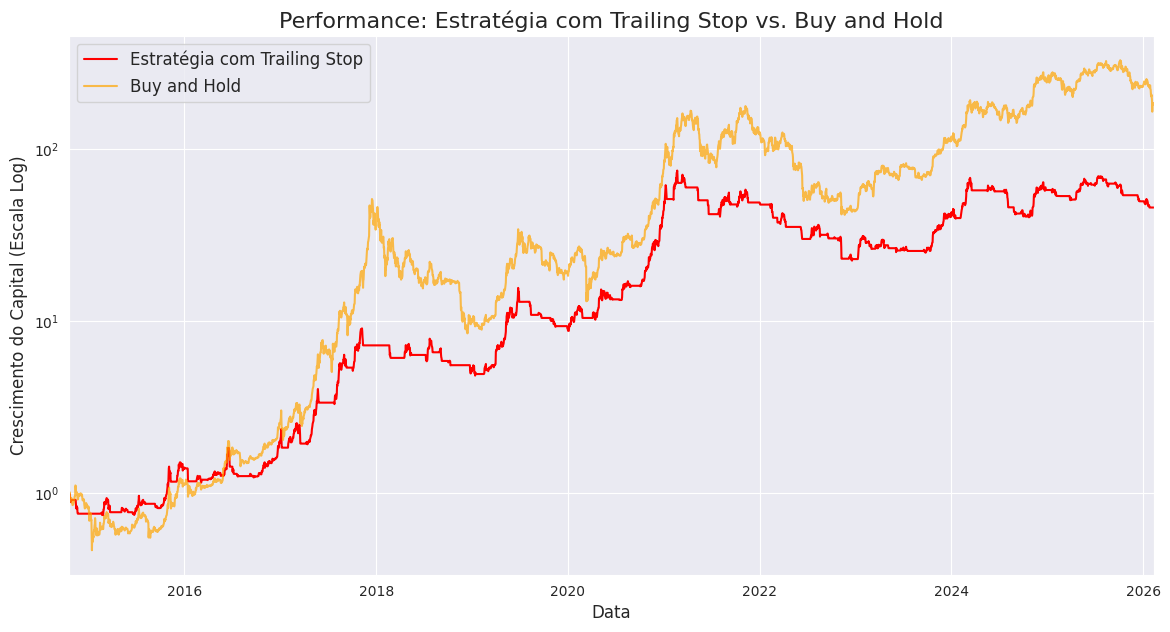


--- MÉTRICAS DA ESTRATÉGIA COM TRAILING STOP ---
- Retorno Total: 45.50x
- Retorno Anualizado: 26.20%
- Volatilidade Anualizada: 34.32%
- Drawdown Máximo: -70.00%
- Índice de Sharpe: 0.76

--- ANÁLISE CONCLUÍDA ---


In [10]:
# Bloco 10: Backtest Robusto com Trailing Stop-Loss
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Garante que o código só rode se o DataFrame 'data' com os preços existir
if 'data' in locals() and not data.empty:

    print("\n--- INICIANDO BACKTEST COM TRAILING STOP-LOSS ---")
    print("Estratégia: SMA 10/30 com Trailing Stop de 15%")

    # 1. Preparação dos Dados e Indicadores
    df_final = data['Close'][['BTC-USD']].copy()
    df_final.rename(columns={'BTC-USD': 'Preco'}, inplace=True)
    df_final.dropna(inplace=True)

    periodo_curto = 10
    periodo_longo = 30
    custo_transacao = 0.001
    trailing_stop_percent = 0.15

    df_final['SMA_Curta'] = df_final['Preco'].rolling(window=periodo_curto).mean()
    df_final['SMA_Longa'] = df_final['Preco'].rolling(window=periodo_longo).mean()
    df_final.dropna(inplace=True)
    print("Indicadores calculados.")

    # 2. Lógica de Trade com Trailing Stop
    # Adicionar colunas de 'shift' para a verificação do cruzamento de forma segura
    df_final['SMA_Curta_Anterior'] = df_final['SMA_Curta'].shift(1)
    df_final['SMA_Longa_Anterior'] = df_final['SMA_Longa'].shift(1)

    posicao = 0
    pico_desde_compra = 0
    stop_loss_level = 0
    posicoes = []

    # Iteramos sobre o DataFrame já com as colunas de 'shift'
    for index, row in df_final.iterrows():
        # Lógica de Entrada (Golden Cross)
        if posicao == 0 and row['SMA_Curta'] > row['SMA_Longa'] and row['SMA_Curta_Anterior'] <= row['SMA_Longa_Anterior']:
            posicao = 1
            pico_desde_compra = row['Preco']
            stop_loss_level = pico_desde_compra * (1 - trailing_stop_percent)

        # Lógica de Saída
        elif posicao == 1:
            pico_desde_compra = max(pico_desde_compra, row['Preco'])
            stop_loss_level = max(stop_loss_level, pico_desde_compra * (1 - trailing_stop_percent))

            # Saída por Death Cross
            if row['SMA_Curta'] < row['SMA_Longa'] and row['SMA_Curta_Anterior'] >= row['SMA_Longa_Anterior']:
                posicao = 0
                pico_desde_compra = 0
                stop_loss_level = 0
            # Saída por Trailing Stop
            elif row['Preco'] < stop_loss_level:
                posicao = 0
                pico_desde_compra = 0
                stop_loss_level = 0

        posicoes.append(posicao)

    df_final['Posicao'] = posicoes
    df_final['Posicao'] = df_final['Posicao'].shift(1).fillna(0)
    print("Sinais e posições com Trailing Stop gerados.")

    # 3. Cálculo de Retornos e Performance
    df_final['Retorno_Diario'] = df_final['Preco'].pct_change()
    df_final['Trade'] = df_final['Posicao'].diff().abs()
    df_final['Custo'] = df_final['Trade'] * custo_transacao
    df_final['Retorno_Estrategia'] = (df_final['Retorno_Diario'] * df_final['Posicao']) - df_final['Custo']
    df_final.dropna(inplace=True)

    df_final['Crescimento_Estrategia'] = (1 + df_final['Retorno_Estrategia']).cumprod()
    df_final['Crescimento_BuyAndHold'] = (1 + df_final['Retorno_Diario']).cumprod()
    print("Crescimento do capital calculado.")

    # 4. Visualização e Métricas
    plt.figure(figsize=(14, 7))
    df_final['Crescimento_Estrategia'].plot(label='Estratégia com Trailing Stop', color='red')
    df_final['Crescimento_BuyAndHold'].plot(label='Buy and Hold', color='orange', alpha=0.7)
    plt.title('Performance: Estratégia com Trailing Stop vs. Buy and Hold', fontsize=16)
    plt.ylabel('Crescimento do Capital (Escala Log)', fontsize=12)
    plt.xlabel('Data', fontsize=12)
    plt.legend(fontsize=12)
    plt.yscale('log')
    plt.show()

    retorno_total_strat = df_final['Crescimento_Estrategia'].iloc[-1]
    retorno_anual_strat = (retorno_total_strat)**(252/len(df_final)) - 1
    vol_anual_strat = df_final['Retorno_Estrategia'].std() * np.sqrt(252)
    sharpe_ratio_strat = retorno_anual_strat / vol_anual_strat if vol_anual_strat > 0 else 0
    max_drawdown_strat = ((df_final['Crescimento_Estrategia'] - df_final['Crescimento_Estrategia'].cummax()) / df_final['Crescimento_Estrategia'].cummax()).min()

    print("\n--- MÉTRICAS DA ESTRATÉGIA COM TRAILING STOP ---")
    metricas = {
        "Retorno Total": f"{retorno_total_strat:.2f}x",
        "Retorno Anualizado": f"{retorno_anual_strat:.2%}",
        "Volatilidade Anualizada": f"{vol_anual_strat:.2%}",
        "Drawdown Máximo": f"{max_drawdown_strat:.2%}",
        "Índice de Sharpe": f"{sharpe_ratio_strat:.2f}"
    }
    for nome, valor in metricas.items():
        print(f"- {nome}: {valor}")

    print("\n--- ANÁLISE CONCLUÍDA ---")

else:
    print("\nO DataFrame 'data' não foi encontrado. Por favor, execute os blocos de código anteriores primeiro.")
